## `unicode1` Understanding Unicode

In [18]:
chr(0)

'\x00'

In [19]:
print(chr(0))

 


In [20]:
sentence = "this is a test" + chr(0) + "string"
print(sentence)

this is a test string


In [22]:
test_string = "hello! こんにちは!"
utf8_encoded = test_string.encode("utf-8")
print(utf8_encoded)
print(type(utf8_encoded))
tuple(utf8_encoded)

b'hello! \xe3\x81\x93\xe3\x82\x93\xe3\x81\xab\xe3\x81\xa1\xe3\x81\xaf!'
<class 'bytes'>


(104,
 101,
 108,
 108,
 111,
 33,
 32,
 227,
 129,
 147,
 227,
 130,
 147,
 227,
 129,
 171,
 227,
 129,
 161,
 227,
 129,
 175,
 33)

In [26]:
# Get the byte values for the encoded string (integers from 0 to 255).
list(utf8_encoded)

[104,
 101,
 108,
 108,
 111,
 33,
 32,
 227,
 129,
 147,
 227,
 130,
 147,
 227,
 129,
 171,
 227,
 129,
 161,
 227,
 129,
 175,
 33]

In [27]:
# One byte does not necessarily correspond to one Unicode character!
print(len(test_string)) 
print(len(utf8_encoded)) 
print(utf8_encoded.decode("utf-8"))  # Decode the bytes back to a string

13
23
hello! こんにちは!


# TinyStory dataset

In [15]:
import os
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import sys

In [3]:
# ====================== CONFIG ======================
DATA_DIR = "/rds/rds-lxu/study_data/stanford_cs336/TinyStories"   # Change if your files are elsewhere
TRAIN_FILE = os.path.join(DATA_DIR, "TinyStoriesV2-GPT4-train.txt")
VALID_FILE = os.path.join(DATA_DIR, "TinyStoriesV2-GPT4-valid.txt")

In [16]:
# Number of sample stories to print
NUM_SAMPLES = 5
# ====================================================

def load_stories(filepath):
    """Load stories from the .txt file (one story per line)"""
    with open(filepath, "r", encoding="utf-8") as f:
        stories = [line.strip() for line in f if line.strip()]
    return stories

def get_basic_stats(stories, name="Dataset"):
    lengths = [len(s) for s in stories]
    word_counts = [len(s.split()) for s in stories]
    
    print(f"\n{'='*60}")
    print(f"{name} Statistics")
    print(f"{'='*60}")
    print(f"Number of stories     : {len(stories):,}")
    print(f"Average length (chars): {sum(lengths)/len(lengths):.1f}")
    print(f"Median length (chars) : {sorted(lengths)[len(lengths)//2]}")
    print(f"Min length            : {min(lengths)}")
    print(f"Max length            : {max(lengths)}")
    print(f"Average words         : {sum(word_counts)/len(word_counts):.1f}")
    print(f"{'='*60}\n")
    
    return lengths, word_counts

def show_sample_stories(stories, n=NUM_SAMPLES):
    print(f"\n=== Sample Stories ({n} random examples) ===\n")
    samples = random.sample(stories, min(n, len(stories)))
    for i, story in enumerate(samples, 1):
        print(f"--- Story {i} ---")
        print(story[:800] + "..." if len(story) > 800 else story)
        print()

def plot_length_distribution(lengths, name="Train"):
    plt.figure(figsize=(10, 5))
    sns.histplot(lengths, bins=100, kde=True, color='skyblue')
    plt.title(f"Story Length Distribution ({name}) - Characters", fontsize=14)
    plt.xlabel("Length (characters)")
    plt.ylabel("Number of Stories")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def get_memory_usage(obj, name="Object"):
    """Calculate approximate memory usage in bytes and MB"""
    # Size of the list object itself
    list_size = sys.getsizeof(obj)
    
    # Size of all strings inside the list
    strings_size = sum(sys.getsizeof(s) for s in obj)
    
    total_bytes = list_size + strings_size
    total_mb = total_bytes / (1024 ** 2)
    
    print(f"\n{name} Memory Usage:")
    print(f"  Number of stories     : {len(obj):,}")
    print(f"  Type                  : {type(obj)}")
    print(f"  List overhead         : {list_size:,} bytes")
    print(f"  Strings total         : {strings_size:,} bytes")
    print(f"  Total in-memory size  : {total_bytes:,} bytes  ({total_mb:.2f} MB)")
    print(f"  Average per story     : {total_bytes / len(obj):.1f} bytes")
    
    return total_bytes

In [17]:
stories = load_stories(VALID_FILE)
print(len(load_stories(VALID_FILE)))
print(type(load_stories(VALID_FILE)))
load_stories(VALID_FILE)
get_memory_usage(stories)

147257
<class 'list'>

Object Memory Usage:
  Number of stories     : 147,257
  Type                  : <class 'list'>
  List overhead         : 1,283,160 bytes
  Strings total         : 28,654,271 bytes
  Total in-memory size  : 29,937,431 bytes  (28.55 MB)
  Average per story     : 203.3 bytes


29937431

Loading TinyStories dataset...

TinyStories Train (V2-GPT4) Statistics
Number of stories     : 14,548,094
Average length (chars): 151.9
Median length (chars) : 166
Min length            : 1
Max length            : 4928
Average words         : 30.2


TinyStories Valid (V2-GPT4) Statistics
Number of stories     : 147,257
Average length (chars): 151.6
Median length (chars) : 166
Min length            : 1
Max length            : 3153
Average words         : 30.1


=== Sample Stories (5 random examples) ===

--- Story 1 ---
Anna liked to play with her dolls. She had many dolls, but her favorite was Lily. Lily had long hair, a pink dress, and a smile. Anna and Lily did everything together. They ate, they read, they sang, and they slept.

--- Story 2 ---
<|endoftext|>

--- Story 3 ---
Once upon a time, there were two friends, Tom and Tia. They were playing in the park one day and came across an old shed. Tom said to Tia, "Let's play in there! It looks like fun!"

--- Story 4 ---
Soon, it was 

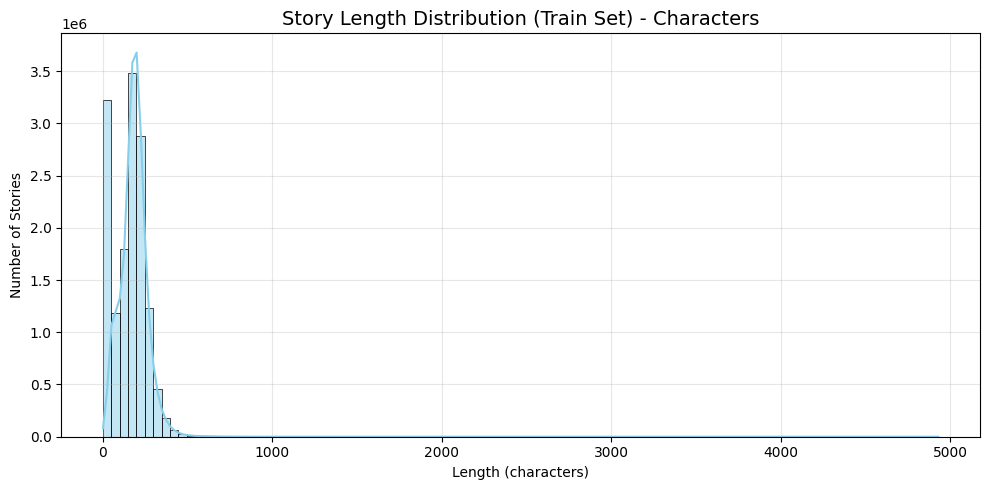


=== Quick Word Frequency (first 20 stories) ===
the             : 28
was             : 20
and             : 19
his             : 13
day             : 8
with            : 8
bob             : 8
ben             : 7
ollie           : 7
one             : 6
very            : 6
vase            : 6
home            : 6
friends         : 6
they            : 6
fish            : 6
big             : 6
tim             : 6
amazing         : 5
said            : 5


In [5]:
print("Loading TinyStories dataset...")

# Load train set
train_stories = load_stories(TRAIN_FILE)
train_lengths, train_words = get_basic_stats(train_stories, "TinyStories Train (V2-GPT4)")

# Load validation set (optional)
if os.path.exists(VALID_FILE):
    valid_stories = load_stories(VALID_FILE)
    valid_lengths, _ = get_basic_stats(valid_stories, "TinyStories Valid (V2-GPT4)")

# Show sample stories
show_sample_stories(train_stories)

# Plot distributions
plot_length_distribution(train_lengths, "Train Set")

# Optional: Show top frequent words (very basic)
print("\n=== Quick Word Frequency (first 20 stories) ===")
all_text = " ".join(train_stories[:20]).lower()
words = [w.strip(".,!?\"'()") for w in all_text.split() if len(w) > 2]
common = Counter(words).most_common(20)
for word, count in common:
    print(f"{word:15} : {count}")